In [1]:
from time_series_gan.TimeWGAN import TimeWGAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting
import torch.nn as nn

c:\Users\sducr\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data = pd.read_csv("data/data_gdp.csv")
archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [64, 21, 30], 'activation': 'ReLU'}, 'critic': {'architecture': 'MLP', 'layer_sizes': [80, 57, 1], 'activation': 'ReLU'}}
params = {'lr_g': 0.0005526, 'lr_c': 0.001336, 'lr_e': 0.002986, 'lr_r': 0.001287, 'epochs': 150, 'batch_size': 14, 'latent_dim': 10, 'hidden_dim': 30, 'seq_length': 10, 'n_critic': 4, 'lambda_gp': 0.188}
model = TimeWGAN()
model.set_data(data)
model.fit(architectures= archi, params = params)

fit took 21.792737 seconds


{}

In [6]:
n = 20

w = np.array([model.compute_val_metric(dWasserstein, {}) for _ in range(n)])
print("Wasserstein", w.mean(), w.std())

f = np.array([model.compute_val_metric(dFrechet, {}) for _ in range(n)])
print("Fréchet", f.mean(), f.std())

o = np.array([model.compute_val_metric(ONND, {}) for _ in range(n)])
print("ONND", o.mean(), o.std())

s = np.array([model.compute_val_metric(score, {}) for _ in range(n)])
print("Score", s.mean(), s.std())

Wasserstein 0.37283694820695096 0.09024568145847532
Fréchet 1.3969428608441563 0.23998820407076948
ONND 0.04172283432067707 0.02951815409449785
Score 4.720238481240615 1.088225768036586


In [ ]:
archi = Metropolis_Hasting(0.1, data, TimeWGAN, ite = 500, metrique=score, nom_de_la_métrique = "score")

fit took 6.044701 seconds
MH étape : 0
modification des paramètres
fit took 12.144080 seconds
succes
6.2792922104885225 ->  5.791543048270214

{'lr_g': 0.000818, 'lr_c': 0.0008223, 'lr_e': 0.001724, 'lr_r': 0.001437, 'epochs': 150, 'batch_size': 12, 'latent_dim': 18, 'hidden_dim': 19, 'seq_length': 10, 'n_critic': 3, 'lambda_gp': 0.1834}
generator : [19]        ReLU
critic : [1]        ReLU


MH étape : 1
modification des paramètres
fit took 21.211434 seconds
echec


MH étape : 2
suppression d'une couche du generator
fit took 13.735520 seconds
echec


MH étape : 3
modification des paramètres
fit took 6.083725 seconds
echec


MH étape : 4
modification des paramètres
fit took 10.025254 seconds
echec


MH étape : 5
modification des paramètres
fit took 6.470802 seconds
echec


MH étape : 6
ajout d'une couche au generator
fit took 14.990426 seconds
echec


MH étape : 7
ajout d'une couche au generator
fit took 14.187334 seconds
echec


MH étape : 8
modification des paramètres
fit took 13.299

Epoch [1/150] Loss AE: 33.3480, Loss D: -3.1521, Loss G: 0.1440, 
Epoch [2/150] Loss AE: 1.6683, Loss D: -5.7608, Loss G: 0.3408, 
Epoch [3/150] Loss AE: 0.3720, Loss D: -22.3077, Loss G: 0.6435, 
Epoch [4/150] Loss AE: 0.4256, Loss D: -56.5261, Loss G: 0.9057, 
Epoch [5/150] Loss AE: 1.0675, Loss D: -99.2627, Loss G: 0.5113, 
Epoch [6/150] Loss AE: 0.4670, Loss D: -68.7639, Loss G: -0.2030, 
Epoch [7/150] Loss AE: 0.1337, Loss D: -75.0164, Loss G: 1.7582, 
Epoch [8/150] Loss AE: 0.1259, Loss D: -86.1772, Loss G: 0.9807, 
Epoch [9/150] Loss AE: 0.0844, Loss D: -91.0555, Loss G: -2.2622, 
Epoch [10/150] Loss AE: 0.0596, Loss D: -60.1219, Loss G: -1.7906, 
Epoch [11/150] Loss AE: 0.0501, Loss D: -60.0049, Loss G: -3.3687, 
Epoch [12/150] Loss AE: 0.0236, Loss D: -43.1330, Loss G: -2.7752, 
Epoch [13/150] Loss AE: 0.0273, Loss D: -20.5145, Loss G: -0.8112, 
Epoch [14/150] Loss AE: 0.0236, Loss D: -25.2861, Loss G: -1.5222, 
Epoch [15/150] Loss AE: 0.0287, Loss D: -33.6804, Loss G: -4.9892

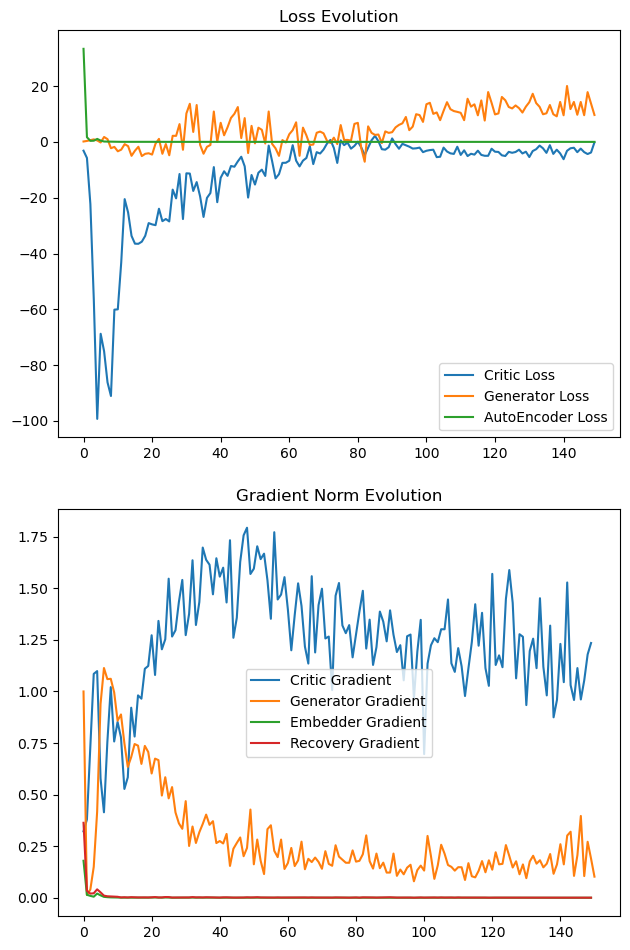

Autoencoder Reconstruction Loss: 0.0104


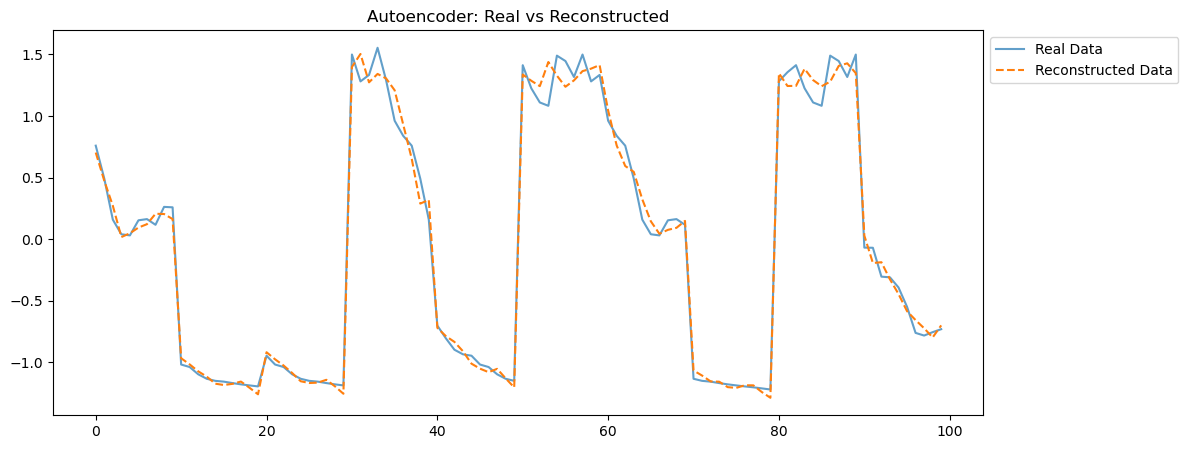

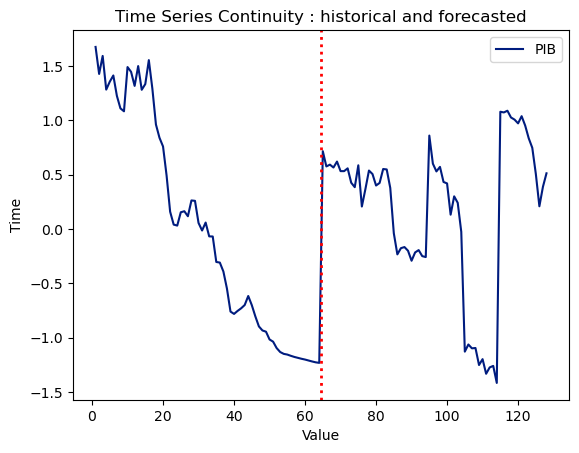

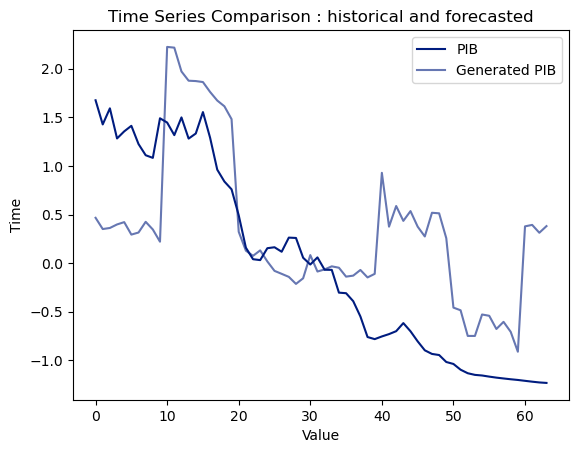

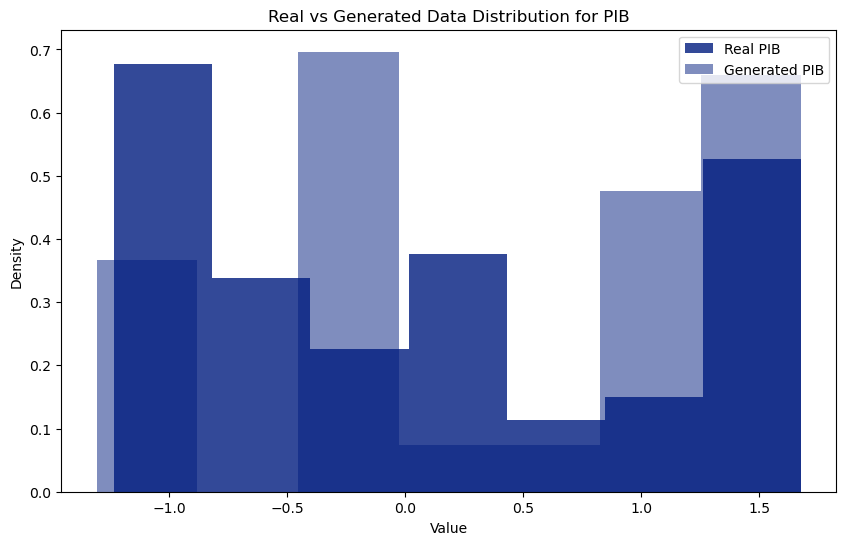

fit took 13.706649 seconds
Wasserstein 0.43461979359324227
Fréchet 1.255740731768933
ONND 0.034367770101460124
Score 6.577304358660042


In [23]:
model = TimeWGAN()
model.set_data(data)
params = {'lr_g': 0.0005526, 'lr_c': 0.001336, 'lr_e': 0.002986, 'lr_r': 0.001287, 'epochs': 150, 'batch_size': 14, 'latent_dim': 10, 'hidden_dim': 30, 'seq_length': 10, 'n_critic': 4, 'lambda_gp': 0.188}
# print(archi)
model.fit(architectures = archi, params = params, verbose= True)
print("Wasserstein", model.compute_val_metric(dWasserstein, {}))
print("Fréchet", model.compute_val_metric(dFrechet, {}))
print("ONND", model.compute_val_metric(ONND, {}))
print("Score", model.compute_val_metric(score, {}))

In [26]:
model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_c": [5e-6, 5e-3],"lr_e": [5e-6, 5e-3], "lr_r": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [8,300], "latent_dim": [1,150], "hidden_dim" : [20, 100], "seq_length" : [6, 50], "n_critic" : [1,5], 'lambda_gp': [0.01, 0.5]}, n_trials = 150)

[I 2025-04-22 23:00:52,735] A new study created in memory with name: no-name-4d3a693f-4ee2-44cd-a288-96e28f593c4f


fit took 3.047587 seconds


[I 2025-04-22 23:00:56,083] Trial 0 finished with value: 8.688514073753787 and parameters: {'lr_g': 0.004530222530737059, 'lr_c': 0.0008816374687044216, 'lr_e': 0.004099178937616347, 'lr_r': 0.002474842367836307, 'epochs': 105, 'batch_size': 35, 'latent_dim': 20, 'hidden_dim': 75, 'seq_length': 9, 'n_critic': 1, 'lambda_gp': 0.3401037018968992}. Best is trial 0 with value: 8.688514073753787.


fit took 4.331756 seconds


[I 2025-04-22 23:01:01,094] Trial 1 finished with value: 3.992331133176334 and parameters: {'lr_g': 0.0003284554187164757, 'lr_c': 0.002358881588454548, 'lr_e': 0.004085431775451741, 'lr_r': 0.0028619481913609744, 'epochs': 99, 'batch_size': 17, 'latent_dim': 49, 'hidden_dim': 67, 'seq_length': 37, 'n_critic': 3, 'lambda_gp': 0.16691186139085004}. Best is trial 1 with value: 3.992331133176334.


...

[I 2025-04-22 23:01:19,351] Trial 13 finished with value: 14.361286987106494 and parameters: {'lr_g': 0.0021275369441821246, 'lr_c': 0.0016237482338076787, 'lr_e': 0.004987985184755557, 'lr_r': 0.003228610595507152, 'epochs': 87, 'batch_size': 166, 'latent_dim': 106, 'hidden_dim': 60, 'seq_length': 36, 'n_critic': 5, 'lambda_gp': 0.1369865771369388}. Best is trial 1 with value: 3.992331133176334.


fit took 10.515590 seconds


[I 2025-04-22 23:01:30,450] Trial 14 finished with value: 8.062999916073874 and parameters: {'lr_g': 0.0007622838297412877, 'lr_c': 3.9288539420138284e-05, 'lr_e': 0.0034628243241415493, 'lr_r': 0.00203448684424811, 'epochs': 115, 'batch_size': 16, 'latent_dim': 63, 'hidden_dim': 42, 'seq_length': 19, 'n_critic': 4, 'lambda_gp': 0.029139233749517546}. Best is trial 1 with value: 3.992331133176334.
[W 2025-04-22 23:01:30,732] Trial 15 failed with parameters: {'lr_g': 0.002718162311299698, 'lr_c': 0.0010200345351624068, 'lr_e': 0.0028120950198647727, 'lr_r': 0.0033093224242110907, 'epochs': 134, 'batch_size': 72, 'latent_dim': 25, 'hidden_dim': 68, 'seq_length': 36, 'n_critic': 2, 'lambda_gp': 0.19518005955709705} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\sducr\miniconda3\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\s

fit took 0.050809 seconds


KeyboardInterrupt: 

In [28]:
print(model.parameters)
params = {'lr_g': 0.0004436857879336777, 'lr_c': 0.0010008678077540072, 'lr_e': 0.0032730094380056833, 'lr_r': 0.004466529729539223, 'epochs': 93, 'batch_size': 18, 'latent_dim': 55, 'hidden_dim': 74, 'seq_length': 41, 'n_critic': 4, 'lambda_gp': 0.08720941653566838}

{'lr_g': 0.002718162311299698, 'lr_c': 0.0010200345351624068, 'lr_e': 0.0028120950198647727, 'lr_r': 0.0033093224242110907, 'epochs': 134, 'batch_size': 72, 'latent_dim': 25, 'hidden_dim': 68, 'seq_length': 36, 'n_critic': 2, 'lambda_gp': 0.19518005955709705}


Epoch [1/93] Loss AE: 3.5370, Loss D: -25.9326, Loss G: 12.3778, 
Epoch [2/93] Loss AE: 64.5283, Loss D: -73.9307, Loss G: 31.3771, 
Epoch [3/93] Loss AE: 2.0447, Loss D: -63.2526, Loss G: 50.4606, 
Epoch [4/93] Loss AE: 2.1605, Loss D: -133.5066, Loss G: 79.4819, 
Epoch [5/93] Loss AE: 2.0733, Loss D: -242.6957, Loss G: 99.3847, 
Epoch [6/93] Loss AE: 0.7926, Loss D: -345.2542, Loss G: 100.4626, 
Epoch [7/93] Loss AE: 0.5717, Loss D: -308.5512, Loss G: 108.6964, 
Epoch [8/93] Loss AE: 0.5038, Loss D: -303.7689, Loss G: 104.2645, 
Epoch [9/93] Loss AE: 0.4093, Loss D: -311.4114, Loss G: 145.2576, 
Epoch [10/93] Loss AE: 0.3709, Loss D: -294.4728, Loss G: 107.7070, 
Epoch [11/93] Loss AE: 0.5050, Loss D: -330.6216, Loss G: 115.7122, 
Epoch [12/93] Loss AE: 0.3922, Loss D: -298.9294, Loss G: 78.1191, 
Epoch [13/93] Loss AE: 0.3425, Loss D: -277.7648, Loss G: 109.7253, 
Epoch [14/93] Loss AE: 0.2496, Loss D: -238.2689, Loss G: 96.9099, 
Epoch [15/93] Loss AE: 0.2681, Loss D: -202.9935, Lo

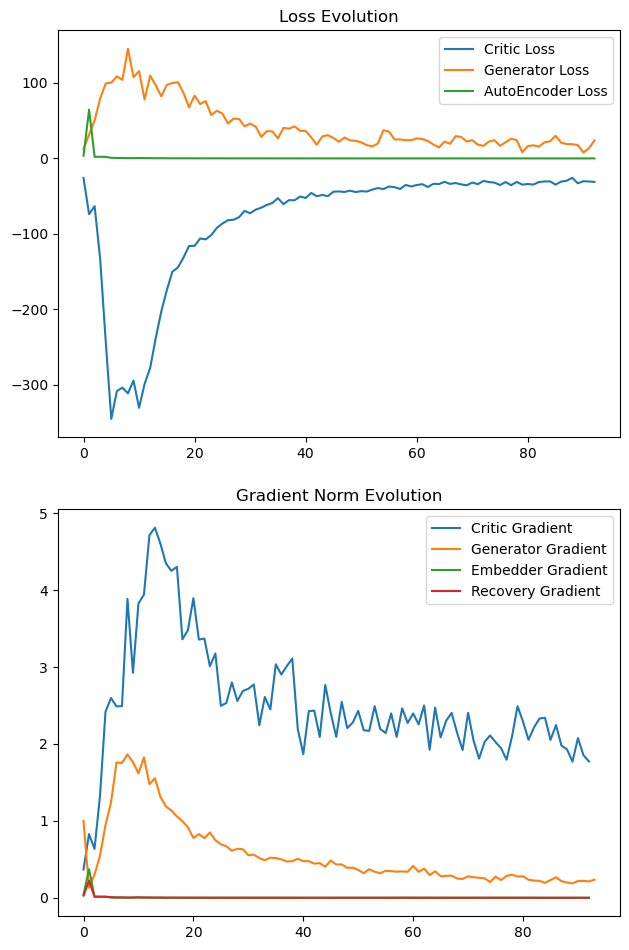

Autoencoder Reconstruction Loss: 0.0276


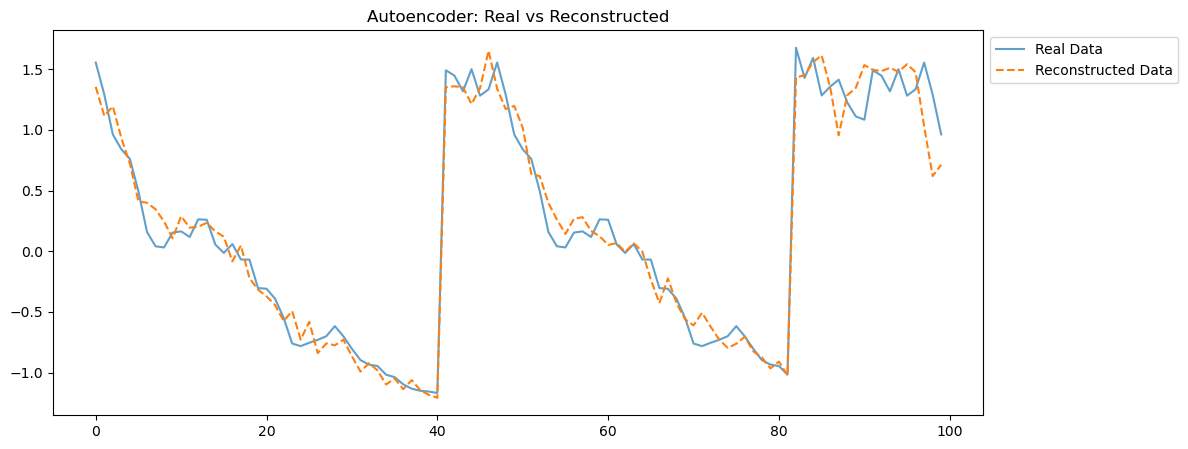

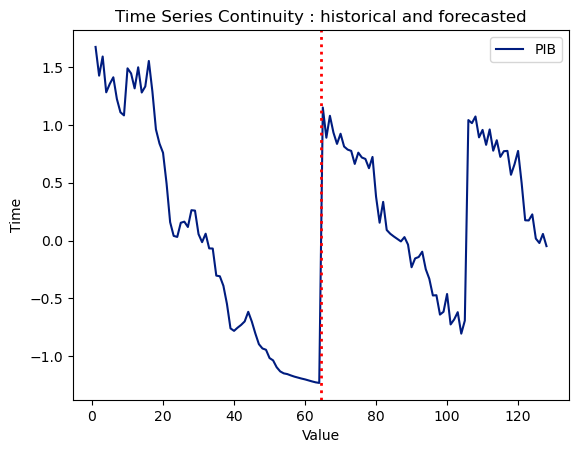

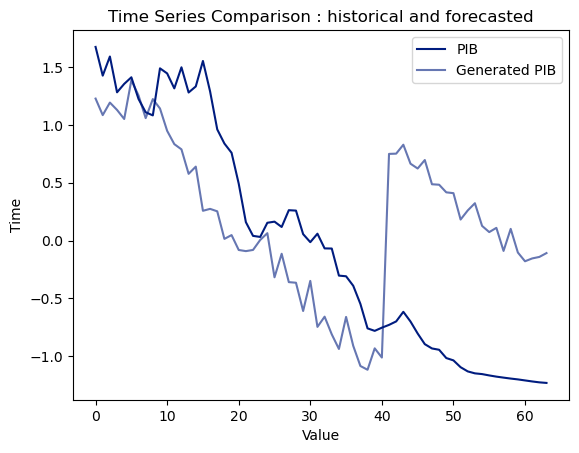

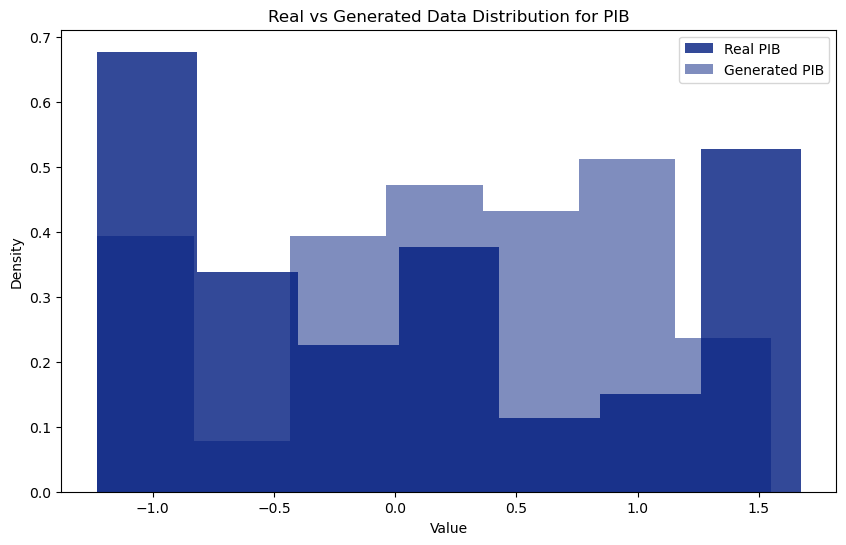

fit took 6.319357 seconds


{}

In [29]:
model.fit(verbose = True, params = params)

In [34]:
print("Wasserstein", model.compute_val_metric(dWasserstein, {}))
print("Fréchet", model.compute_val_metric(dFrechet, {}))
print("ONND", model.compute_val_metric(ONND, {}))
print("Score", model.compute_val_metric(score, {}))

Wasserstein 0.16526430450822377
Fréchet 0.7578643116768211
ONND 0.021162239646467986
Score 2.000137194891666
